In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/syedaeman2212/chocolate-sales-dataset-in-2025/chocolate_sales_2025_dataset.csv


## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/syedaeman2212/chocolate-sales-dataset-in-2025/chocolate_sales_2025_dataset.csv")

In [3]:
df.head()

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
0,1,2025-11-24,Cadbury,Milk Chocolate,France,Supermarket,Digital Wallet,5.00,194,970.00
1,2,2025-02-22,Lindt,Chocolate Bar,India,Online,Cash,17.73,144,2553.12
2,3,2025-02-17,Toblerone,Dark Chocolate,Australia,Supermarket,Digital Wallet,7.42,134,994.28
3,4,2025-11-29,Ferrero,Truffles,Italy,Convenience Store,Cash,18.28,112,2047.36
4,5,2025-03-23,Cadbury,Milk Chocolate,France,Convenience Store,Cash,18.21,92,1675.32


In [4]:
df.tail()

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
495,496,2025-08-11,Cadbury,Milk Chocolate,France,Specialty Store,Digital Wallet,6.03,30,180.90
496,497,2025-10-11,Toblerone,White Chocolate,UAE,Convenience Store,Cash,18.75,191,3581.25
497,498,2025-02-19,Toblerone,Truffles,Germany,Online,Card,3.62,151,546.62
498,499,2025-01-02,Nestle,Chocolate Box,Italy,Specialty Store,Cash,12.12,80,969.60
499,500,2025-02-19,Mars,White Chocolate,UK,Specialty Store,Cash,3.08,48,147.84


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sale_ID         500 non-null    int64  
 1   Date            500 non-null    object 
 2   Brand           500 non-null    object 
 3   Product_Type    500 non-null    object 
 4   Country         500 non-null    object 
 5   Sales_Channel   500 non-null    object 
 6   Payment_Method  500 non-null    object 
 7   Price_USD       500 non-null    float64
 8   Units_Sold      500 non-null    int64  
 9   Revenue_USD     500 non-null    float64
dtypes: float64(2), int64(2), object(6)
memory usage: 39.2+ KB


In [6]:
df.describe()

,Sale_ID,Price_USD,Units_Sold,Revenue_USD
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,13.779860,104.938000,1433.391140
std,144.481833,6.484013,56.263998,1065.679386
min,1.000000,2.520000,5.000000,20.480000
25%,125.750000,8.592500,56.750000,562.545000
50%,250.500000,13.480000,108.500000,1197.225000
75%,375.250000,19.445000,150.250000,2072.812500
max,500.000000,25.000000,200.000000,4809.260000


In [7]:
df.isnull().sum()

Sale_ID           0
Date              0
Brand             0
Product_Type      0
Country           0
Sales_Channel     0
Payment_Method    0
Price_USD         0
Units_Sold        0
Revenue_USD       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Sale_ID             int64
Date               object
Brand              object
Product_Type       object
Country            object
Sales_Channel      object
Payment_Method     object
Price_USD         float64
Units_Sold          int64
Revenue_USD       float64
dtype: object

In [10]:
df.shape

(500, 10)

In [11]:
df.nunique()

Sale_ID           500
Date              274
Brand               7
Product_Type        6
Country            10
Sales_Channel       4
Payment_Method      3
Price_USD         452
Units_Sold        180
Revenue_USD       497
dtype: int64

In [12]:
df.columns

Index(['Sale_ID', 'Date', 'Brand', 'Product_Type', 'Country', 'Sales_Channel',
       'Payment_Method', 'Price_USD', 'Units_Sold', 'Revenue_USD'],
      dtype='object')

In [13]:
# Style
sns.set(style="whitegrid")


# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

## EDA

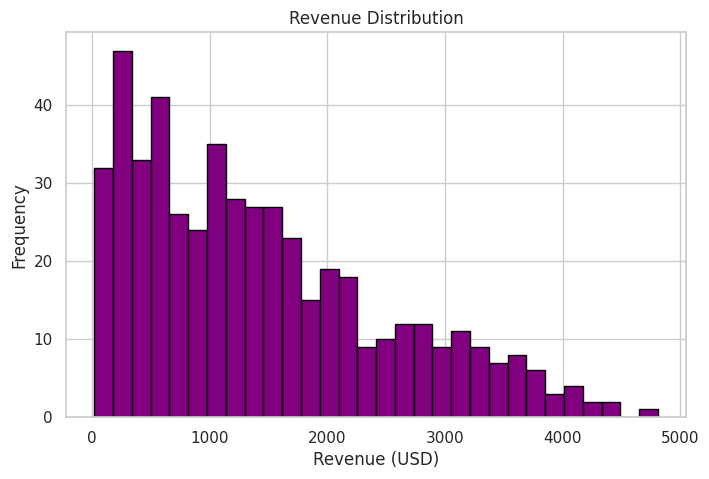

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df["Revenue_USD"], bins=30, color="purple", edgecolor="black")
plt.title("Revenue Distribution")
plt.xlabel("Revenue (USD)")
plt.ylabel("Frequency")
plt.show()

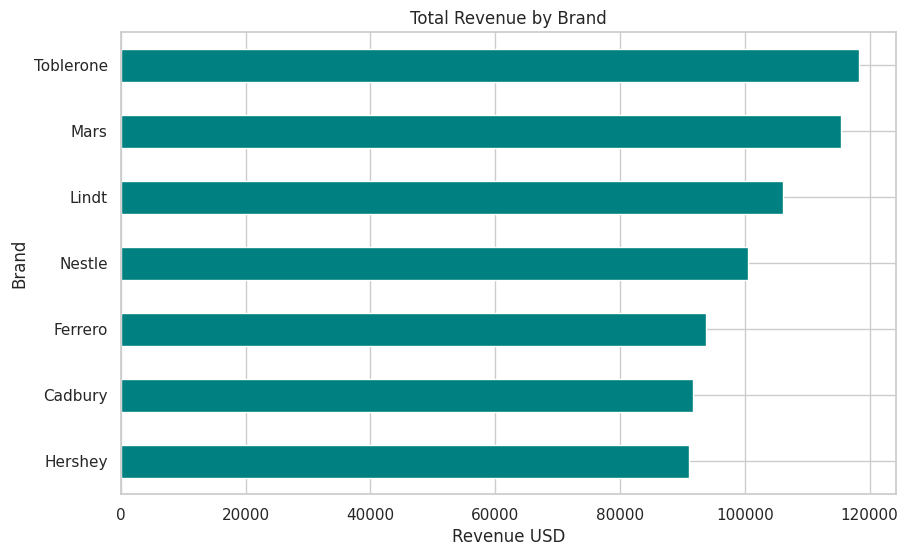

In [15]:
brand_revenue = df.groupby("Brand")["Revenue_USD"].sum().sort_values()

plt.figure(figsize=(10,6))
brand_revenue.plot(kind="barh", color="teal")
plt.title("Total Revenue by Brand")
plt.xlabel("Revenue USD")
plt.ylabel("Brand")
plt.show()

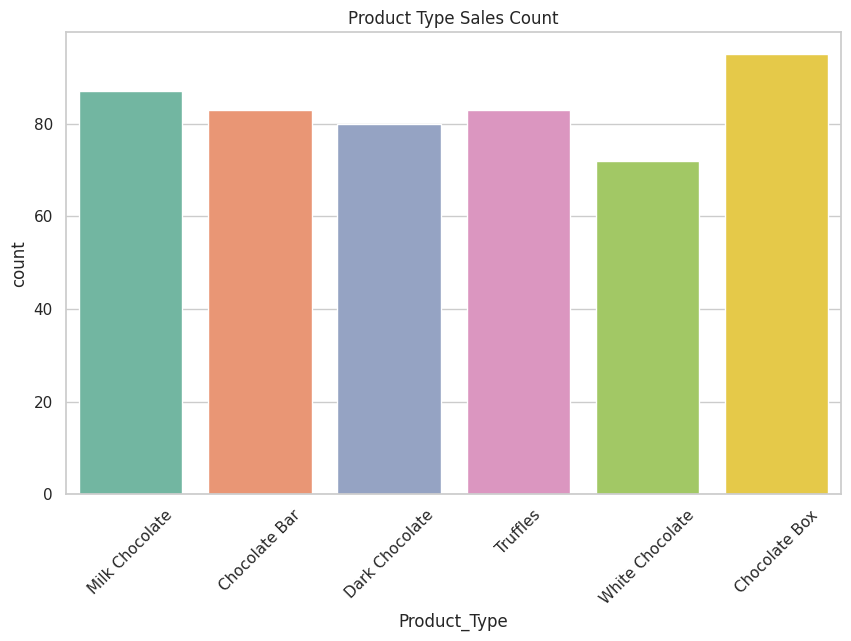

In [16]:
plt.figure(figsize=(10,6))
sns.countplot(x="Product_Type", data=df, palette="Set2")

plt.title("Product Type Sales Count")
plt.xticks(rotation=45)
plt.show()

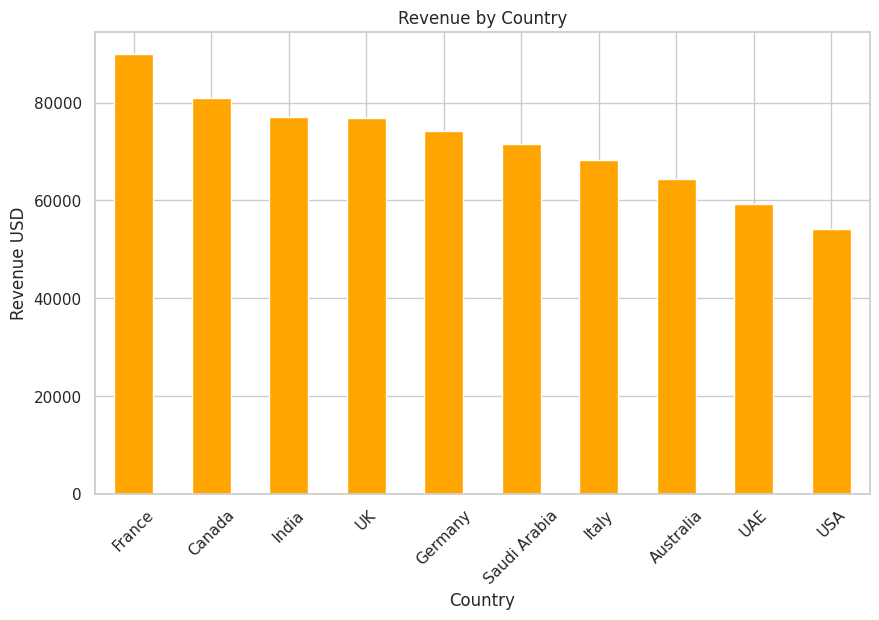

In [17]:
country_revenue = df.groupby("Country")["Revenue_USD"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
country_revenue.plot(kind="bar", color="orange")

plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue USD")
plt.xticks(rotation=45)
plt.show()

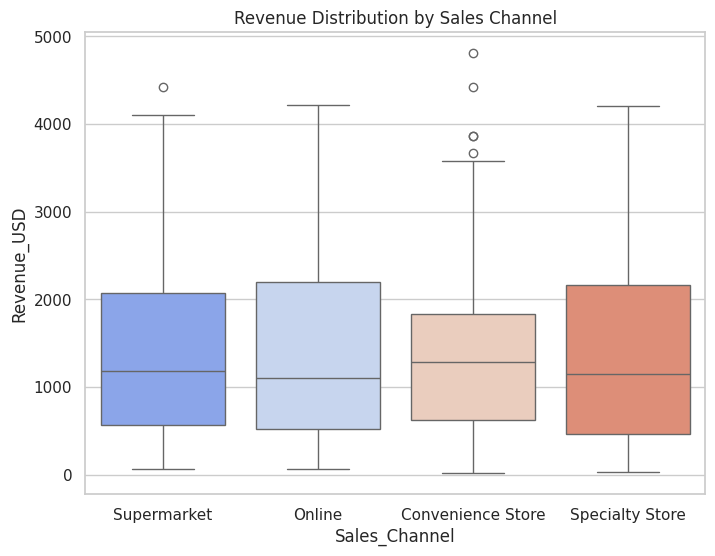

In [18]:
plt.figure(figsize=(8,6))
sns.boxplot(x="Sales_Channel", y="Revenue_USD", data=df, palette="coolwarm")

plt.title("Revenue Distribution by Sales Channel")
plt.show()

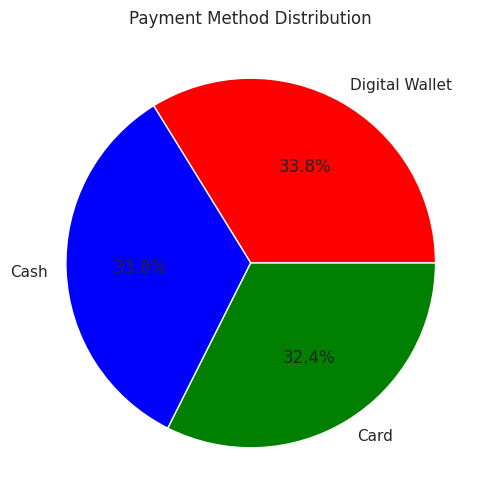

In [19]:
plt.figure(figsize=(8,6))
df["Payment_Method"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["red","blue","green","gold","purple"]
)

plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

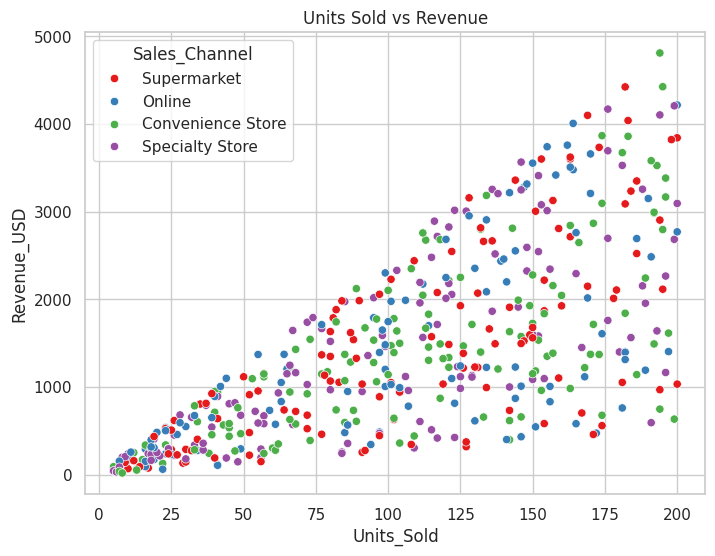

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="Units_Sold",
    y="Revenue_USD",
    hue="Sales_Channel",
    palette="Set1",
    data=df
)

plt.title("Units Sold vs Revenue")
plt.show()

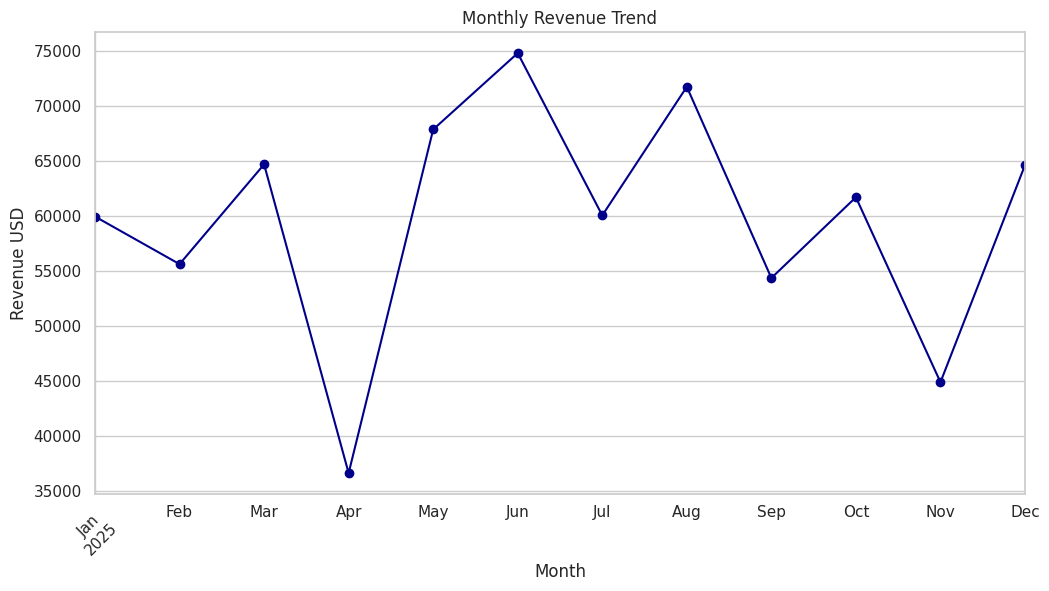

In [21]:
df["Month"] = df["Date"].dt.to_period("M")

monthly_sales = df.groupby("Month")["Revenue_USD"].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot(color="darkblue", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue USD")
plt.xticks(rotation=45)
plt.show()

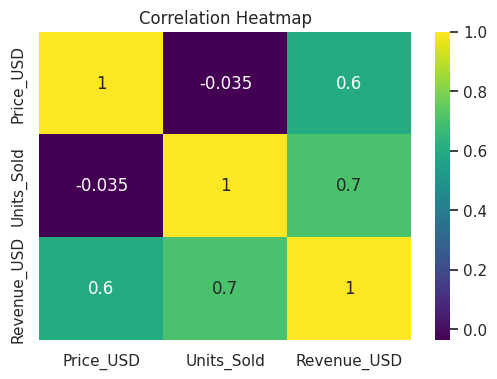

In [22]:
plt.figure(figsize=(6,4))
sns.heatmap(
    df[["Price_USD","Units_Sold","Revenue_USD"]].corr(),
    annot=True,
    cmap="viridis"
)

plt.title("Correlation Heatmap")
plt.show()

## Feature engineering

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [24]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

df.drop("Date", axis=1, inplace=True)

In [25]:
le = LabelEncoder()

categorical_cols = [
    "Brand",
    "Product_Type",
    "Country",
    "Sales_Channel",
    "Payment_Method"
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [26]:
X = df.drop("Sales_Channel", axis=1)
y = df["Sales_Channel"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [28]:
models = {

"Logistic Regression": LogisticRegression(max_iter=1000),

"Decision Tree": DecisionTreeClassifier(),

"Random Forest": RandomForestClassifier(),

"SVM": SVC(probability=True),

"KNN": KNeighborsClassifier(),

"Naive Bayes": GaussianNB()

}

In [29]:
classes = np.unique(y)

y_test_bin = label_binarize(y_test, classes=classes)

n_classes = y_test_bin.shape[1]


MODEL: Logistic Regression
Accuracy: 23.0 %


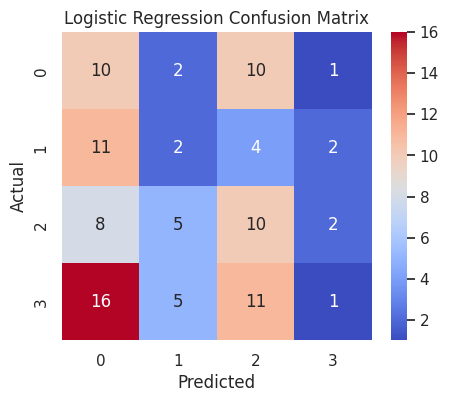

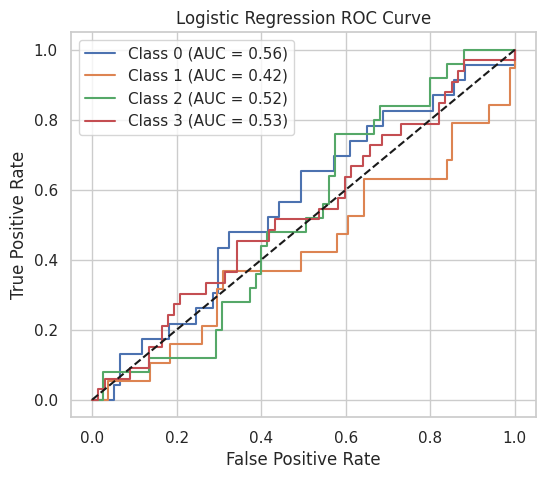


MODEL: Decision Tree
Accuracy: 19.0 %


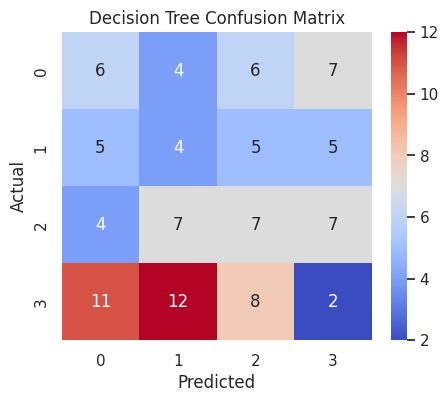

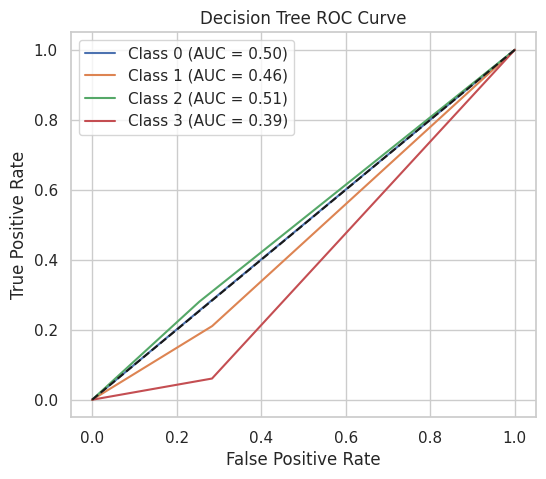


MODEL: Random Forest
Accuracy: 22.0 %


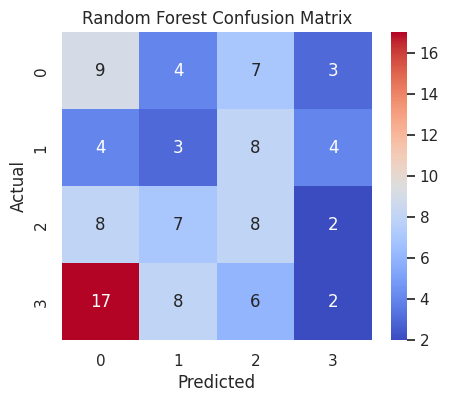

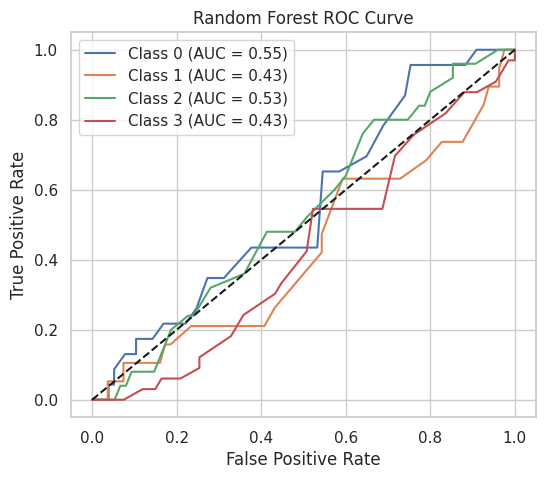


MODEL: SVM
Accuracy: 22.0 %


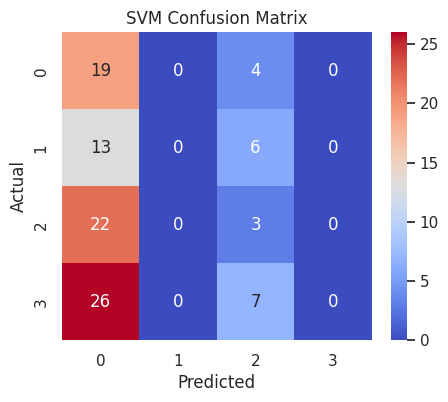

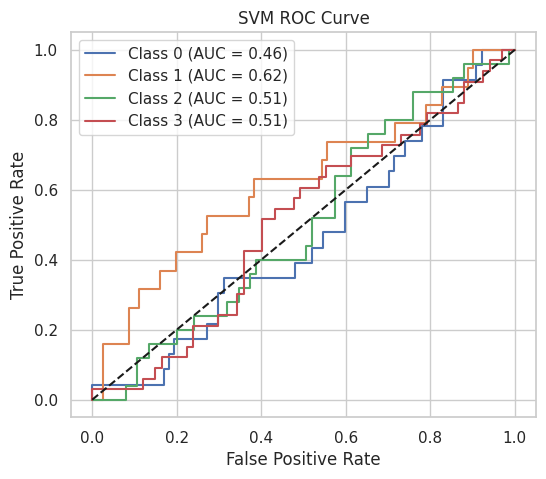


MODEL: KNN
Accuracy: 16.0 %


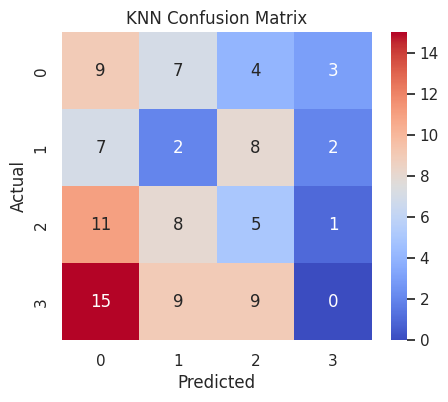

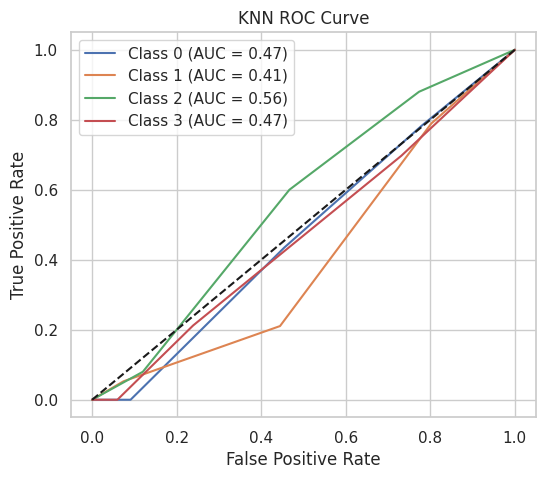


MODEL: Naive Bayes
Accuracy: 21.0 %


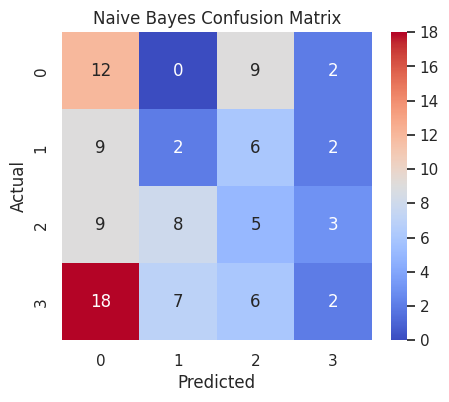

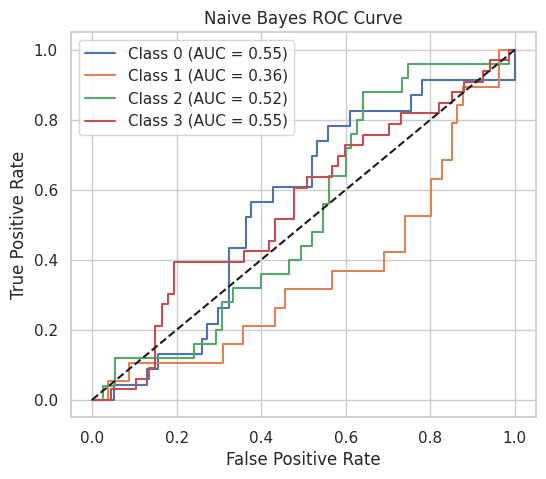

In [30]:
for name, model in models.items():

    print("\n" + "="*60)
    print("MODEL:", name)
    print("="*60)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print("Accuracy:", round(accuracy*100,2), "%")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm")

    plt.title(name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve (Multiclass)

    y_prob = model.predict_proba(X_test)

    plt.figure(figsize=(6,5))

    for i in range(n_classes):

        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])

        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label="Class %d (AUC = %0.2f)" % (i, roc_auc))

    plt.plot([0,1],[0,1],'k--')

    plt.title(name + " ROC Curve")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.legend()

    plt.show()

## Thank you..pls upvote!!!!!!!!!!!
